# 07 · Business Impact, Decisioning & Explainability

Load the champion model from `06`, translate its predictions into **money and analyst workload**, then explain *why* it flags transactions with SHAP. Everything here is on the held-out **test** set at the cost-optimal threshold chosen on validation.

In [1]:
# project-root bootstrap
import os
from pathlib import Path
_p=Path.cwd()
while not (_p/'config'/'config.yaml').exists() and _p!=_p.parent:
    _p=_p.parent
os.chdir(_p); print('working dir:', Path.cwd())

working dir: /Users/asfalanoi/app_2026/fraud_detection


In [2]:
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fraud.io import load_pickle, read_parquet
from fraud.costs import confusion_costs, precision_at_k
from fraud.config import load_config

cfg = load_config('config/config.yaml')
ch  = load_pickle('models/champion_xgb.pkl')
pre, model, t_star = ch['preprocessor'], ch['model'], ch['threshold']
FP_COST, FEATURES = ch['fp_cost'], ch['features']

test = read_parquet('data/processed/test.parquet')
X_test = pre.transform(test[FEATURES])
y_test = test.Class.values
amt    = test.Amount.values
proba  = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= t_star).astype(int)
print(f'test rows={len(y_test):,}  frauds={int(y_test.sum())}  threshold={t_star:.4f}')

test rows=28,481  frauds=49  threshold=0.1875


## The dollar story

Baseline = approve everything (lose every fraudulent dollar). The model's value is the money it recovers, net of analyst review cost.

In [3]:
c = confusion_costs(y_test, y_pred, amt, fp_cost=FP_COST)
baseline_loss = float(amt[y_test == 1].sum())          # all fraud lost
fraud_caught_pct = c['fraud_caught_$'] / max(baseline_loss, 1e-9)
pnl = pd.DataFrame([
    ('Fraud $ at risk (no model)', -baseline_loss),
    ('Fraud $ recovered (caught)',  c['fraud_caught_$']),
    ('Fraud $ still lost (missed)', -c['fraud_missed_$']),
    ('Analyst review cost (FPs)',  -c['fp_$']),
    ('NET $ SAVED vs baseline',     c['net_saved_$']),
], columns=['line item', '$'])
pnl['$'] = pnl['$'].round(2)
print(f"fraud dollars recovered: {fraud_caught_pct*100:.1f}%")
pnl

fraud dollars recovered: 64.0%


,line item,$
0,Fraud $ at risk (no model),-4003.06
1,Fraud $ recovered (caught),2560.73
2,Fraud $ still lost (missed),-1266.33
3,Analyst review cost (FPs),-64.00
4,NET $ SAVED vs baseline,2496.73


## Analyst capacity — precision@k

If the team can review only *k* alerts, how many are real fraud? This sets staffing and tells us the alert queue is worth working.

In [4]:
rows = []
for k in [25, 50, 100, 200]:
    rows.append({'k (alerts)': k, 'precision@k': round(precision_at_k(y_test, proba, k), 3),
                 'frauds in top-k': int(round(precision_at_k(y_test, proba, k) * k))})
pak = pd.DataFrame(rows)
K = cfg.cost.k
print(f'At the configured capacity k={K}, precision@k = {precision_at_k(y_test, proba, K):.3f}')
pak

At the configured capacity k=100, precision@k = 0.450


,k (alerts),precision@k,frauds in top-k
0,25,1.00,25
1,50,0.86,43
2,100,0.45,45
3,200,0.23,46


## Why are transactions flagged? (SHAP)

Global feature importance from SHAP on the underlying gradient-boosted model — what actually drives the fraud score.

In [5]:
import shap
# unwrap calibrated -> FrozenEstimator -> XGBClassifier
xgb = model.calibrated_classifiers_[0].estimator.estimator
NAMES = [f'V{i}' for i in range(1, 29)] + ['log_amount', 'amount_robust', 'hour_sin', 'hour_cos']
rng = np.random.default_rng(0)
idx = rng.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
Xs = np.asarray(X_test)[idx]
expl = shap.TreeExplainer(xgb)
sv = expl.shap_values(Xs)
mean_abs = np.abs(sv).mean(axis=0)
imp = pd.Series(mean_abs, index=NAMES).sort_values(ascending=False)
shap_top = imp.head(8).index.tolist()
imp.head(8)

V14    2.636264
V4     2.369240
V12    1.215565
V10    1.003650
V11    0.843964
V3     0.774449
V7     0.624250
V16    0.620230
dtype: float32

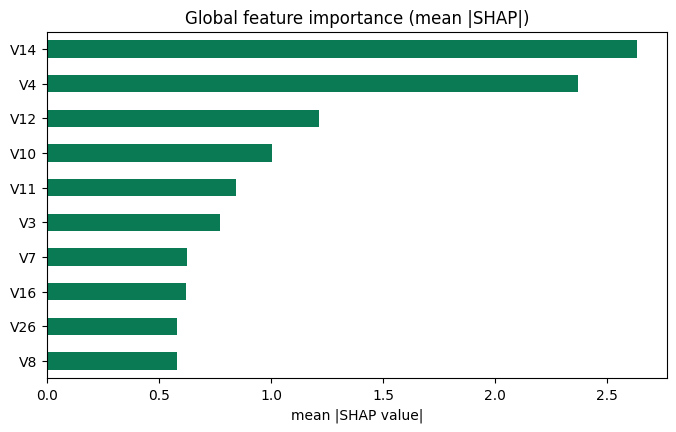

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
imp.head(10)[::-1].plot.barh(ax=ax, color='#0a7a55')
ax.set(title='Global feature importance (mean |SHAP|)', xlabel='mean |SHAP value|')
fig.savefig('reports/figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# A single caught-fraud case: why was THIS transaction flagged?
caught = np.where((y_test == 1) & (y_pred == 1))[0]
row = int(caught[0])
sv_row = expl.shap_values(np.asarray(X_test)[row:row+1])[0]
contrib = pd.Series(sv_row, index=NAMES).sort_values(key=np.abs, ascending=False).head(6)
print(f'transaction #{row}: amount=${amt[row]:.2f}  fraud_prob={proba[row]:.3f}  (actual fraud)')
print('top drivers (+ pushes toward fraud):')
contrib.round(3)

transaction #1040: amount=$1.00  fraud_prob=1.000  (actual fraud)
top drivers (+ pushes toward fraud):


V14    4.302
V4     2.163
V10    1.693
V3     1.631
V12    1.344
V7     1.302
dtype: float32

## Persist results for the executive report

In [8]:
results = {
    'net_saved':        round(c['net_saved_$'], 2),
    'baseline_loss':    round(baseline_loss, 2),
    'fraud_caught_pct': round(fraud_caught_pct, 4),
    'threshold':        round(float(t_star), 4),
    'recall':           round(float(ch['metrics_test']['recall']), 4),
    'precision':        round(float(ch['metrics_test']['precision']), 4),
    'pr_auc':           round(float(ch['metrics_test']['pr_auc']), 4),
    'roc_auc':          round(float(ch['metrics_test']['roc_auc']), 4),
    'precision_at_k':   round(precision_at_k(y_test, proba, cfg.cost.k), 3),
    'k':                cfg.cost.k,
    'shap_top':         shap_top,
    'figures': ['../figures/threshold_sweep.png', '../figures/confusion_matrices.png',
                '../figures/diagnostics.png', '../figures/robustness_segments.png',
                '../figures/shap_summary.png'],
}
os.makedirs('reports', exist_ok=True)
with open('reports/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('wrote reports/results.json')
results

wrote reports/results.json


{'net_saved': 2496.73,
 'baseline_loss': 4003.06,
 'fraud_caught_pct': 0.6397,
 'threshold': 0.1875,
 'recall': 0.898,
 'precision': 0.7333,
 'pr_auc': 0.8855,
 'roc_auc': 0.9774,
 'precision_at_k': 0.45,
 'k': 100,
 'shap_top': ['V14', 'V4', 'V12', 'V10', 'V11', 'V3', 'V7', 'V16'],
 'figures': ['../figures/threshold_sweep.png',
  '../figures/confusion_matrices.png',
  '../figures/diagnostics.png',
  '../figures/robustness_segments.png',
  '../figures/shap_summary.png']}

**Next:** `08_unsupervised_appendix` (Isolation Forest baseline) then `09_business_insights` (executive HTML report).